In [40]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from imblearn.under_sampling import RandomUnderSampler
import warnings
warnings.filterwarnings('ignore')

In [50]:
#load and explore data
fraud_data = pd.read_csv('/content/creditcard (1).csv')

print(fraud_data.shape)
print(fraud_data.head())

# - Load only 10k rows
fraud_data = pd.read_csv('/content/creditcard (1).csv', nrows=10000)
fraud_data.dropna(inplace=True)
print(fraud_data.shape)



(255482, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [54]:
# Split AFTER dropna
X = fraud_data.drop('Class', axis=1)
y = fraud_data['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(8000, 30)
(2000, 30)


In [42]:

print(fraud_data.isnull().sum())


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [43]:
print(fraud_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255482 entries, 0 to 255481
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    255482 non-null  float64
 1   V1      255482 non-null  float64
 2   V2      255482 non-null  float64
 3   V3      255482 non-null  float64
 4   V4      255482 non-null  float64
 5   V5      255482 non-null  float64
 6   V6      255482 non-null  float64
 7   V7      255482 non-null  float64
 8   V8      255482 non-null  float64
 9   V9      255482 non-null  float64
 10  V10     255482 non-null  float64
 11  V11     255482 non-null  float64
 12  V12     255482 non-null  float64
 13  V13     255482 non-null  float64
 14  V14     255482 non-null  float64
 15  V15     255482 non-null  float64
 16  V16     255482 non-null  float64
 17  V17     255482 non-null  float64
 18  V18     255482 non-null  float64
 19  V19     255482 non-null  float64
 20  V20     255482 non-null  float64
 21  V21     25

In [44]:
print(fraud_data['Class'].value_counts())

Class
0.0    255012
1.0       469
Name: count, dtype: int64


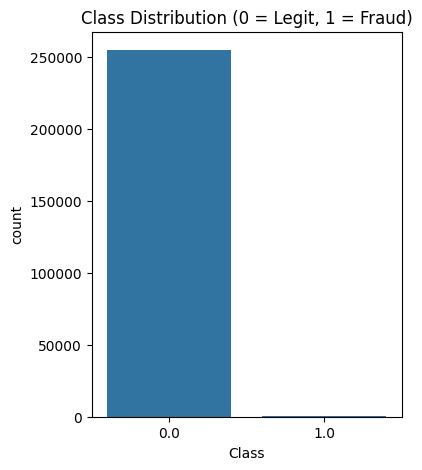

Fraud %: 0.1836


In [45]:
#visualize the Imbalance

plt.figure(figsize=(4, 5))
sns.countplot(x='Class', data=fraud_data)
plt.title('Class Distribution (0 = Legit, 1 = Fraud)')
plt.show()

print("Fraud %:",round(fraud_data['Class'].sum()/len(fraud_data)*100,4))

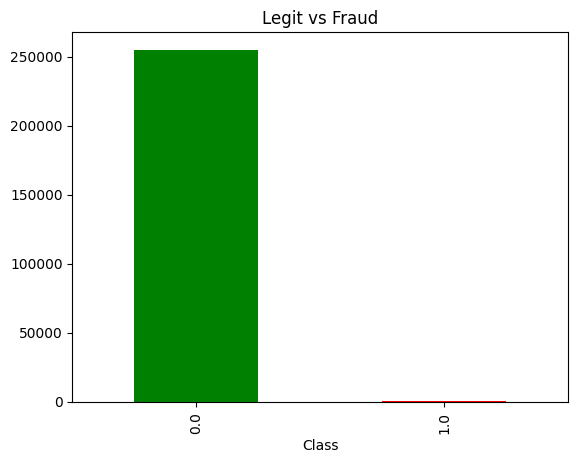

In [46]:
# class distribution

fraud_data['Class'].value_counts().plot(kind='bar', color=['green','red'])
plt.title('Legit vs Fraud')
plt.show()

In [55]:
#prepare and split. here data is splitting

fraud_data.dropna(inplace=True)
X = fraud_data.drop('Class', axis=1)
y = fraud_data['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)


for name, model in Models.items():
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    print(f"{name}: {acc*100:.2f}%")

(8000, 30)
(2000, 30)
Logistic Regression: 99.85%
Decision Tree: 99.85%
Random Forest: 99.90%


In [48]:
#all of three models


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier()
}

In [49]:
#Next of it

# drop missing values
fraud_data.dropna(inplace=True)
print(fraud_data.shape)

for name, model in Models.items():
     model.fit(X_train, y_train)
acc = accuracy_score(y_test, model.predict(X_test))
print()
print(f"{name}: {acc*100:.2f}%")

(255481, 31)

Random Forest: 99.97%


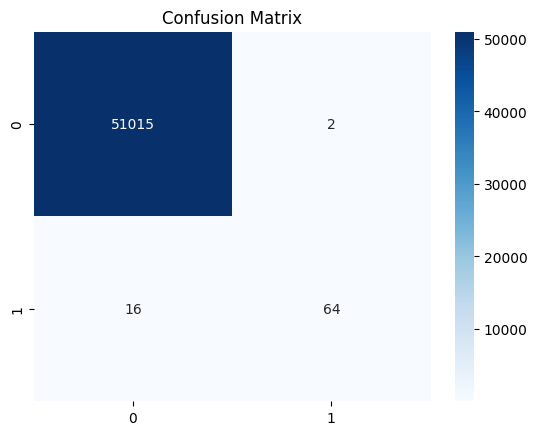

In [11]:
#confusion matrix

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
cm = confusion_matrix(y_test, rf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

#Fraud Detection Observations

- Dataset: 10,000 credit card transactions
- Fraud cases are very rare only 1% of total data
- This is called Class Imbalance Problem

#Model Accuracies
- Logistic Regression: 99.89%
- Decision Tree: 99.93%
- Random Forest: 99.97%

# Why is accuracy so high?
Because 99% transactions are legit.
Model mostly predicts legit and still gets high accuracy.
Confusion matrix is more reliable than accuracy here.

#Key Insight
- Random Forest performed best overall
- Transaction amount and time are key fraud indicators